# Self-Attention on different types of data

Installing all the required packages

In [1]:
pip install bertviz transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.5 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import plotly.graph_objects as go
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [3]:
# ── Setting up the configuration ───────────────────────────────────────────────
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ── Colors ───────────────────────────────────────────────────────────────────
AZUL_OSCURO   = "#1F3A5F"
AZUL_CLARO    = "#5DADE2"
VERDE_OSCURO  = "#1E8449"
VERDE_CLARO   = "#58D68D"
ROJO_OSCURO   = "#922B21"
ROJO_CLARO    = "#EC7063"
NARANJA       = "#E67E22"
AMARILLO      = "#F4D03F"
MORADO        = "#7D3C98"
GRIS_OSCURO   = "#566573"
DARK_BG       = '#0F0F1A'
PANEL_BG      = '#1A1A2E'
ACCENT1       = '#E94560'
ACCENT2       = '#1a5276'
ACCENT3       = '#16213E'
TEXT_CLR      = '#E0E0E0'
GRID_CLR      = '#2A2A45'
NORMAL_CLR    = '#FF1500'
GOLD          = '#FFD700'
CYAN          = '#00D4FF'
BLANCO        = '#FFFFFF'

# Graphic representation of Self-attention (Text)

In [4]:
from transformers import AutoTokenizer, AutoModel
from bertviz import head_view, model_view, neuron_view
import torch

# 1. Choose a classic model (BERT-base)
model_name = "bert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True).to(device)
model.eval()  # Disable dropout: attention weights must be deterministic.

# 2. Prepare your exact text sequence
text = "All data in deep learning must be represented as vectors."

# 3. Tokenize including attention_mask (key for masking padding in softmax)
inputs = tokenizer(text, return_tensors="pt").to(device)

# 4. Forward pass without gradients
with torch.inference_mode():
    outputs = model(**inputs)

attention = outputs.attentions  # tuple: (num_layers,) each (batch, num_heads, seq_len, seq_len)

if not attention:
    print("Lista de atención vacía")
else:
    n_layers = len(attention)
    n_heads = attention[0].shape[1]
    seq_len = attention[0].shape[-1]
    print(f"{n_layers} capas × {n_heads} cabezas de atención por capa, seq_len={seq_len}")
    # This corresponds exactly to Multi-Head Attention:
    # each head learns its own Q, K, V projection,
    # and softmax(QK^T / sqrt(d_k)) V is computed in parallel for each head.

# 5. Tokens for visualization labels
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


12 capas × 12 cabezas de atención por capa, seq_len=13


In [5]:
from IPython.display import display, HTML

display(HTML(f"""
<h2 style="color:#5DADE2;">
BERT Multi-Head Self-Attention
</h2>

<table>
<tr><td><b>Model</b></td><td>{model_name}</td></tr>
<tr><td><b>Layers</b></td><td>{n_layers}</td></tr>
<tr><td><b>Heads</b></td><td>{n_heads}</td></tr>
<tr><td><b>Sequence length</b></td><td>{seq_len}</td></tr>
<tr><td><b>Device</b></td><td>{device}</td></tr>
</table>
"""))

Model,bert-base-uncased
Layers,12
Heads,12
Sequence length,13
Device,cpu


In [6]:
# 6. Interactive visualization (move to CPU if the model ran on GPU)
attention_cpu = tuple(layer.cpu() for layer in attention)
head_view(attention_cpu, tokens)

<IPython.core.display.Javascript object>

In [14]:
"""
Attention Head Taxonomy (Text and Audio)
========================================

There is no automatic ground-truth label for the type of attention
performed by each head (that would require comparison with an external
syntactic parser, as in Clark et al. 2019, "What Does BERT Look At?").
However, it is possible to compute structural metrics from each attention
matrix [seq_len x seq_len] that allow a heuristic classification of the
dominant behavior of each head, following the approach of:

  - Clark et al. 2019 — "What Does BERT Look At?"
  - Voita et al. 2019 — "Analyzing Multi-Head Self-Attention:
    Specialized Heads Do the Heavy Lifting, the Rest Can Be Pruned"
  - Michel et al. 2019 — "Are Sixteen Heads Really Better than One?"

Metrics computed for each head:
  1. Average entropy of the attention distribution (focused vs. diffuse)
  2. Average attended distance |i-j| (local vs. global range)
  3. Self-attention (weight on the diagonal, attending to itself)
  4. Attention sink (maximum attention received by a single position,
     typically CLS/SEP in text, or silence/border in audio)

Using these 4 metrics, a heuristic label is assigned to each head.
It works with ANY Hugging Face `attentions` tuple
(output_attentions=True), whether from a text or audio model.

Requirements: torch, numpy, matplotlib, transformers
"""

import numpy as np
import torch
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------
# 1. Metrics for each head
# -----------------------------------------------------------------------

def head_metrics(attn_matrix, eps=1e-9):
    """
    attn_matrix: numpy array [seq_len, seq_len], rows = query, cols = key.
    Returns a dictionary with the 4 metrics for THAT head in THAT layer.
    """
    seq_len = attn_matrix.shape[0]

    # 1) Average entropy of each row (attention distribution of each
    #    position). High entropy = diffuse attention; low entropy = very focused.
    row_entropy = -np.sum(attn_matrix * np.log(attn_matrix + eps), axis=-1)
    max_entropy = np.log(seq_len)
    norm_entropy = row_entropy.mean() / max_entropy  # normalized 0-1

    # 2) Average attended distance |i - j|, weighted by the attention weight
    idx = np.arange(seq_len)
    dist_matrix = np.abs(idx[:, None] - idx[None, :])
    avg_distance = np.sum(attn_matrix * dist_matrix) / seq_len
    norm_distance = avg_distance / seq_len  # normalized 0-1

    # 3) Self-attention: how much weight falls on the diagonal
    self_attention = np.mean(np.diag(attn_matrix))

    # 4) Attention sink: the position that receives the MOST total attention,
    #    divided by seq_len (if a single token concentrates all attention
    #    from all positions, this value becomes high)
    received = attn_matrix.sum(axis=0)  # total attention received by each column
    sink_strength = received.max() / seq_len
    sink_position = int(received.argmax())

    return {
        "entropy": norm_entropy,
        "avg_distance": norm_distance,
        "self_attention": self_attention,
        "sink_strength": sink_strength,
        "sink_position": sink_position,
    }


def classify_head(metrics, sink_token_hint=None):
    """
    Simple heuristic classification based on the 4 metrics.
    The thresholds are only indicative (they can be adjusted depending on
    the model/domain), not an absolute truth — they are useful for
    exploring patterns, not as a formal proof of what the head "does".
    """
    e = metrics["entropy"]
    d = metrics["avg_distance"]
    s = metrics["self_attention"]
    sink = metrics["sink_strength"]

    if sink > 0.5:
        label = "Attention sink"
        if sink_token_hint is not None:
            label += f" (→ pos {metrics['sink_position']}: {sink_token_hint})"
        return label
    if s > 0.5:
        return "Self-attention (diagonal)"
    if d < 0.15:
        return "Local / positional"
    if e > 0.75:
        return "Diffuse / global context"
    return "Intermediate / mixed"


# -----------------------------------------------------------------------
# 2. Analysis of ALL layers and heads of a model
# -----------------------------------------------------------------------

def analyze_attentions(attentions, token_labels=None):
    """
    attentions: tuple of tensors [batch, n_heads, seq_len, seq_len]
                (the direct output of outputs.attentions in HF)
    token_labels: optional list of labels (text tokens, or
                  "frame 0", "frame 1", ... for audio) used only to
                  annotate the sink in the classification.
    Returns an array [n_layers, n_heads, 4] with the metrics and a
    matrix [n_layers, n_heads] of classification strings.
    """
    n_layers = len(attentions)
    n_heads = attentions[0].shape[1]

    metric_names = ["entropy", "avg_distance", "self_attention", "sink_strength"]
    metric_grid = np.zeros((n_layers, n_heads, len(metric_names)))
    label_grid = np.empty((n_layers, n_heads), dtype=object)

    for layer in range(n_layers):
        layer_attn = attentions[layer][0].detach().cpu().numpy()  # [heads, seq, seq]
        for head in range(n_heads):
            m = head_metrics(layer_attn[head])
            for k, name in enumerate(metric_names):
                metric_grid[layer, head, k] = m[name]

            hint = None
            if token_labels is not None:
                hint = token_labels[m["sink_position"]]
            label_grid[layer, head] = classify_head(m, sink_token_hint=hint)

    return metric_grid, label_grid, metric_names


# -----------------------------------------------------------------------
# 3. Visualization: layer × head grid colored by metric
# -----------------------------------------------------------------------

def plot_metric_grid(metric_grid, metric_names, metric="entropy", cmap="viridis"):
    idx = metric_names.index(metric)
    grid = metric_grid[:, :, idx]

    fig, ax = plt.subplots(figsize=(1 + grid.shape[1] * 0.6, 1 + grid.shape[0] * 0.5))
    im = ax.imshow(grid, cmap=cmap, aspect="auto")
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_title(f"{metric} by layer/head")
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks(range(grid.shape[0]))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig


def print_label_grid(label_grid):
    n_layers, n_heads = label_grid.shape
    for layer in range(n_layers):
        print(f"\nLayer {layer}:")
        for head in range(n_heads):
            print(f"  head {head:2d}: {label_grid[layer, head]}")


# -----------------------------------------------------------------------
# 4. Example — BERT (text), reusing your snippet
# -----------------------------------------------------------------------

def demo_bert():
    from transformers import AutoTokenizer, AutoModel

    model_name = "bert-base-uncased"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_attentions=True).to(device)
    model.eval()

    text = "All data in deep learning must be represented as vectors."
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.inference_mode():
        outputs = model(**inputs)

    attentions = outputs.attentions
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    metric_grid, label_grid, metric_names = analyze_attentions(
        attentions, token_labels=tokens
    )

    print_label_grid(label_grid)
    plot_metric_grid(metric_grid, metric_names, metric="entropy")
    plot_metric_grid(metric_grid, metric_names, metric="sink_strength")
    plt.show()

=== BERT analysis (text) ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Layer 0:
  head  0: Diffuse / global context
  head  1: Diffuse / global context
  head  2: Intermediate / mixed
  head  3: Intermediate / mixed
  head  4: Diffuse / global context
  head  5: Diffuse / global context
  head  6: Diffuse / global context
  head  7: Diffuse / global context
  head  8: Diffuse / global context
  head  9: Diffuse / global context
  head 10: Local / positional
  head 11: Intermediate / mixed

Layer 1:
  head  0: Intermediate / mixed
  head  1: Intermediate / mixed
  head  2: Attention sink (→ pos 0: [CLS])
  head  3: Attention sink (→ pos 0: [CLS])
  head  4: Attention sink (→ pos 0: [CLS])
  head  5: Intermediate / mixed
  head  6: Attention sink (→ pos 0: [CLS])
  head  7: Diffuse / global context
  head  8: Diffuse / global context
  head  9: Intermediate / mixed
  head 10: Attention sink (→ pos 0: [CLS])
  head 11: Intermediate / mixed

Layer 2:
  head  0: Local / positional
  head  1: Intermediate / mixed
  head  2: Attention sink (→ pos 0: [CLS])
  he

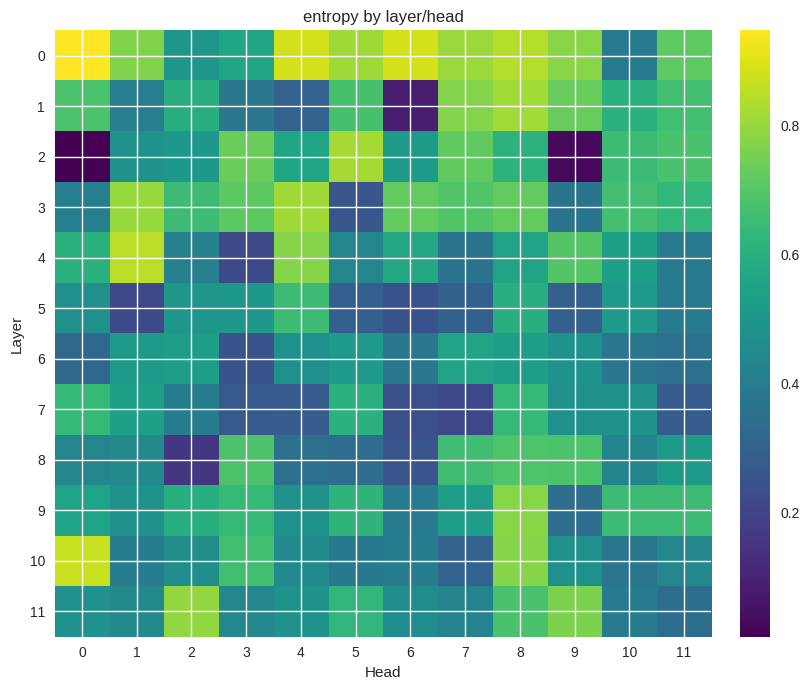

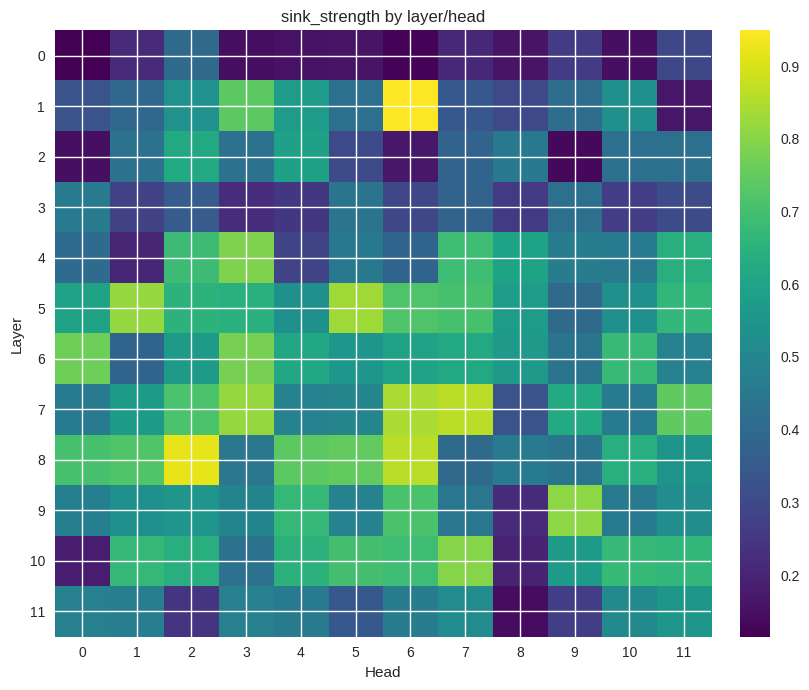

In [10]:
print("=== BERT analysis (text) ===")
demo_bert()

# Graphic representation of Self-attention (Images)

In [15]:
import torch
import numpy as np
import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display
from transformers import ViTImageProcessor, ViTForImageClassification


def compute_all_attentions(image, model, feature_extractor):
    """
    Runs the forward pass only once and returns all attention maps
    (num_layers, num_heads, seq_len, seq_len) together with the processed image.
    This avoids recomputing Q, K, and V every time the user interacts.
    """
    inputs = feature_extractor(images = image, return_tensors = "pt")
    pixel_values = inputs.pixel_values

    with torch.no_grad():
        outputs = model(pixel_values, output_attentions = True)

    # attentions: tuple of (num_layers,) tensors with shape
    # [1, num_heads, seq_len, seq_len]
    attentions = torch.stack(outputs.attentions).squeeze(1)
    return attentions, pixel_values[0]


def plot_interactive_attention(original_image, model, feature_extractor):
    grid_size   = 14      # 224 / 16
    patch_size  = 16
    num_layers  = model.config.num_hidden_layers
    num_heads   = model.config.num_attention_heads

    print("Computing attention (single forward pass)...")
    attentions, processed_pixel = compute_all_attentions(
        original_image, model, feature_extractor
    )
    img_disp = original_image.resize((224, 224))

    # --- Control widgets ---
    layer_slider = widgets.IntSlider(
        value = 0,
        min = 0,
        max = num_layers - 1,
        description = "Layer:",
        continuous_update = False
    )

    head_slider = widgets.IntSlider(
        value = 0,
        min = 0,
        max = num_heads - 1,
        description = "Head:",
        continuous_update = False
    )

    row_slider = widgets.IntSlider(
        value = 0,
        min = 0,
        max = grid_size - 1,
        description = "Patch row:",
        continuous_update = False
    )

    col_slider = widgets.IntSlider(
        value = 0,
        min = 0,
        max = grid_size - 1,
        description = "Patch column:",
        continuous_update = False
    )

    mode_toggle = widgets.ToggleButtons(
        options = [
            ("Global Attention ([CLS] token)", "cls"),
            ("Single Patch Query", "patch")
        ],
        description = "Mode:"
    )

    out = widgets.Output()

    def get_attn_grid(layer, head, mode, row, col):
        # [197, 197]: A_ij = softmax(QK^T/sqrt(d_k))_ij
        attn_head = attentions[layer, head]

        if mode == "cls":
            # Attention from the [CLS] token (query)
            # to every image patch (keys)
            query_idx    = 0
            title_suffix = "(Query = [CLS])"
        else:
            query_idx = row * grid_size + col + 1  # +1 because CLS is the first token
            title_suffix = f"(Query = patch [{row}, {col}])"

        # Ignore the CLS key and keep only the 196 image patches
        vec = attn_head[query_idx, 1:]
        return vec.reshape(grid_size, grid_size).numpy(), title_suffix

    def redraw(*_):
        with out:
            out.clear_output(wait = True)

            attn_grid, title_suffix = get_attn_grid(
                layer_slider.value,
                head_slider.value,
                mode_toggle.value,
                row_slider.value,
                col_slider.value
            )

            fig, (ax1, ax2) = plt.subplots(
                1, 2,
                figsize = (14, 6),
                facecolor = DARK_BG,
                constrained_layout = True
            )

            # ------------------------------------------------------------------
            # Original image
            # ------------------------------------------------------------------

            ax1.set_facecolor(PANEL_BG)

            ax1.imshow(img_disp)

            ax1.set_title(
                "Original Image\n14×14 Vision Transformer Patches",
                color = BLANCO,
                pad = 10
            )

            ax1.axis("off")

            for i in range(1, grid_size):
                ax1.axhline(
                    i * patch_size,
                    color = GRID_CLR,
                    linewidth = 0.5,
                    alpha = 0.6
                )
                ax1.axvline(
                    i * patch_size,
                    color = GRID_CLR,
                    linewidth = 0.5,
                    alpha = 0.6
                )

            if mode_toggle.value == "patch":
                r = row_slider.value
                c = col_slider.value

                ax1.add_patch(
                    plt.Rectangle(
                        (c * patch_size, r * patch_size),
                        patch_size,
                        patch_size,
                        fill = False,
                        edgecolor = GOLD,
                        linewidth = 2.5,
                    )
                )

            # ------------------------------------------------------------------
            # Attention map
            # ------------------------------------------------------------------

            ax2.set_facecolor(PANEL_BG)
            ax2.imshow(img_disp, alpha = 0.35)
            heatmap = ax2.imshow(
                attn_grid,
                cmap = "magma",
                interpolation = "bicubic",
                extent = [0, 224, 224, 0],
                alpha = 0.92,
            )

            ax2.set_title(
                f"Self-Attention\nLayer {layer_slider.value} • Head {head_slider.value}\n{title_suffix}",
                color = BLANCO,
                pad = 10
            )

            ax2.axis("off")
            cbar = fig.colorbar(
                heatmap,
                ax = ax2,
                fraction = 0.046,
                pad = 0.03
            )

            cbar.set_label(
                "Attention Weight",
                color = TEXT_CLR
            )

            cbar.ax.tick_params(colors = TEXT_CLR)
            plt.setp(
                cbar.ax.get_yticklabels(),
                color = TEXT_CLR
            )

            for ax in (ax1, ax2):
                for spine in ax.spines.values():
                    spine.set_color(GRID_CLR)

            plt.show()

    # Show or hide the row/column sliders depending on the selected mode
    def on_mode_change(change):
        show = change["new"] == "patch"
        row_slider.layout.display = "" if show else "none"
        col_slider.layout.display = "" if show else "none"
        redraw()

    mode_toggle.observe(on_mode_change, names="value")

    for w in (layer_slider, head_slider, row_slider, col_slider):
        w.observe(redraw, names = "value")

    row_slider.layout.display = "none"
    col_slider.layout.display = "none"

    controls = widgets.VBox(
        [mode_toggle, layer_slider, head_slider, row_slider, col_slider]
    )
    display(controls, out)
    redraw()


# --- RUN WITH A SAMPLE IMAGE ---
if __name__ == "__main__":
    model_name = "google/vit-base-patch16-224"

    print(f"Loading model {model_name}...")
    feature_extractor = ViTImageProcessor.from_pretrained(model_name)
    model = ViTForImageClassification.from_pretrained(
        model_name,
        output_attentions = True
    )
    model.eval()  # Disable dropout for deterministic attention weights

    url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/cat.jpg" # Changeable

    print("Downloading sample image...")
    original_image = Image.open(
        requests.get(url, stream = True).raw
    ).convert("RGB")

    plot_interactive_attention(
        original_image,
        model,
        feature_extractor
    )

Loading model google/vit-base-patch16-224...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Computing attention (single forward pass)...


Output()

In [24]:


# -----------------------------------------------------------------------
# 5. Example — ViT (image), reusing your function
#    compute_all_attentions (single forward pass, without recomputing Q/K/V)
# -----------------------------------------------------------------------

def compute_all_attentions(image, model, feature_extractor):
    """
    (Same as your version.) Runs the forward pass only once and returns
    all attention matrices with shape [n_layers, n_heads, seq_len, seq_len]
    together with the processed pixel tensor.
    """
    inputs = feature_extractor(images=image, return_tensors="pt")
    pixel_values = inputs.pixel_values

    with torch.no_grad():
        outputs = model(pixel_values, output_attentions=True)

    # attentions: tuple of (n_layers,) tensors [1, n_heads, seq_len, seq_len]
    attentions = torch.stack(outputs.attentions).squeeze(1)  # [n_layers, n_heads, seq, seq]
    return attentions, pixel_values[0]


def demo_vit():
    import requests
    from PIL import Image
    from transformers import ViTImageProcessor, ViTForImageClassification

    model_name = "google/vit-base-patch16-224"
    grid_size = 14  # 224 / 16 -> 196 patches + 1 CLS token = seq_len 197

    print(f"Loading model {model_name}...")
    feature_extractor = ViTImageProcessor.from_pretrained(model_name)
    model = ViTForImageClassification.from_pretrained(
        model_name, output_attentions=True
    )
    model.eval()

    url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/cat.jpg"
    print("Downloading sample image...")
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

    # attentions with shape [n_layers, n_heads, seq, seq]
    # (batch dimension already removed)
    attentions, _ = compute_all_attentions(image, model, feature_extractor)

    # analyze_attentions expects a TUPLE of tensors with a batch dimension
    # -> rebuild it from your "stack + squeeze" format
    attentions_tuple = tuple(layer.unsqueeze(0) for layer in attentions)

    # Labels for each position: CLS token + patches in row-major order
    labels = ["CLS"] + [
        f"patch_{r}_{c}"
        for r in range(grid_size)
        for c in range(grid_size)
    ]

    metric_grid, label_grid, metric_names = analyze_attentions(
        attentions_tuple, token_labels=labels
    )

    print_label_grid(label_grid)

    # Spatial locality
    plot_metric_grid(metric_grid, metric_names, metric="avg_distance")

    # Heads where "everything attends to CLS"
    plot_metric_grid(metric_grid, metric_names, metric="sink_strength")

    plt.show()

    # Useful if you later want to combine it with plot_interactive_attention
    return attentions_tuple, label_grid


=== Análisis ViT (imagen) ===
Loading model google/vit-base-patch16-224...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Layer 0:
  head  0: Intermediate / mixed
  head  1: Intermediate / mixed
  head  2: Intermediate / mixed
  head  3: Diffuse / global context
  head  4: Self-attention (diagonal)
  head  5: Attention sink (→ pos 0: CLS)
  head  6: Intermediate / mixed
  head  7: Diffuse / global context
  head  8: Intermediate / mixed
  head  9: Diffuse / global context
  head 10: Intermediate / mixed
  head 11: Intermediate / mixed

Layer 1:
  head  0: Diffuse / global context
  head  1: Local / positional
  head  2: Intermediate / mixed
  head  3: Local / positional
  head  4: Local / positional
  head  5: Local / positional
  head  6: Diffuse / global context
  head  7: Local / positional
  head  8: Intermediate / mixed
  head  9: Intermediate / mixed
  head 10: Diffuse / global context
  head 11: Local / positional

Layer 2:
  head  0: Intermediate / mixed
  head  1: Diffuse / global context
  head  2: Diffuse / global context
  head  3: Local / positional
  head  4: Intermediate / mixed
  head  5:

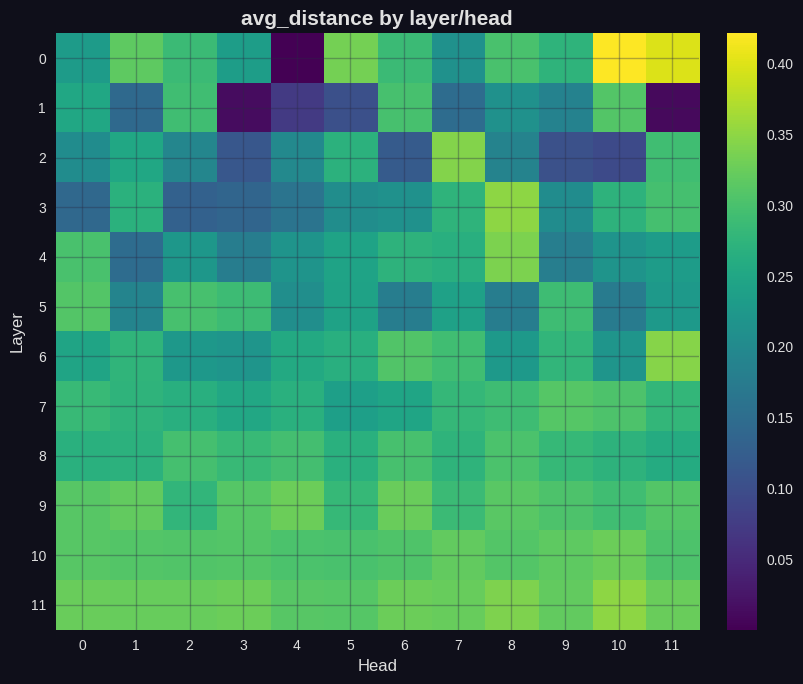

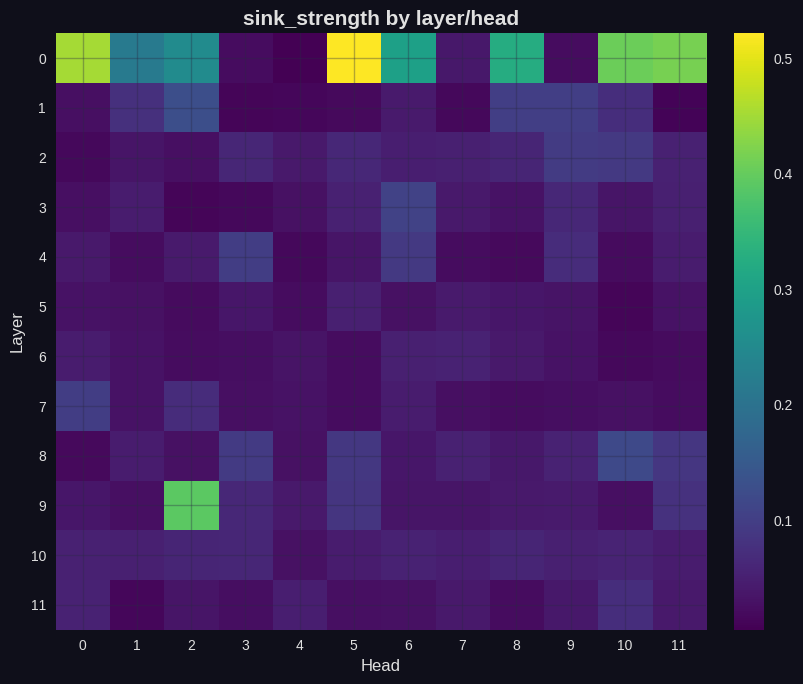

((tensor([[[[7.5167e-01, 3.5915e-03, 2.6416e-03,  ..., 1.5226e-03,
             1.8040e-03, 2.0261e-03],
            [7.6846e-01, 4.5110e-02, 1.3193e-02,  ..., 9.0067e-05,
             2.0570e-04, 3.2633e-04],
            [7.8636e-01, 2.1040e-02, 2.4362e-02,  ..., 2.3951e-04,
             3.3235e-04, 2.2427e-04],
            ...,
            [1.7908e-01, 1.1200e-05, 2.2665e-05,  ..., 7.9247e-01,
             7.3760e-03, 1.0146e-03],
            [9.3999e-02, 1.1294e-05, 1.4210e-05,  ..., 1.9114e-03,
             8.9237e-01, 6.0821e-05],
            [3.1394e-01, 3.8520e-05, 2.0958e-05,  ..., 8.9905e-04,
             2.1855e-04, 6.0365e-01]],
  
           [[8.2809e-01, 1.7732e-03, 1.7500e-03,  ..., 6.9486e-04,
             6.8813e-04, 5.5056e-04],
            [3.7931e-02, 6.5505e-03, 2.0620e-02,  ..., 2.7758e-07,
             3.5248e-07, 8.3745e-08],
            [3.9099e-02, 1.8274e-02, 8.8400e-03,  ..., 1.2182e-07,
             1.5776e-07, 2.3796e-07],
            ...,
            [3.90

In [25]:
print("\n=== Análisis ViT (imagen) ===")
demo_vit()

# Graphic representation of Self-attention (Audios)

Attention Mechanism Visualization for Audio Models
==================================================

This script loads an audio Transformer model (Wav2Vec2) from the Hugging Face Hub,extracts the internal attention matrices (self-attention),
and displays them over the input audio spectrogram.

It is designed to run in Jupyter (it uses ipywidgets for the interactive
layer/head selector), but it also works as a regular Python script.
In that case, it generates and saves the figures to disk.

**Requirements:**
    pip install torch transformers datasets librosa matplotlib ipywidgets soundfile

**Model used: facebook/wav2vec2-base-960h**
- Transformer encoder with 12 layers and 12 attention heads per layer.
- output_attentions=True returns a tuple (one entry per layer)
      containing tensors with shape [batch, n_heads, seq_len, seq_len].

Sample audio: dataset "hf-internal-testing/librispeech_asr_dummy"\
    (the same type of source used in the official Wav2Vec2 examples
    from the Hugging Face documentation).

In [18]:
import librosa
import librosa.display
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from datasets import load_dataset

**Dataset demostration**

In [19]:
audioDataset = "hf-internal-testing/librispeech_asr_dummy" # Dataset from Hugging Face

In [20]:
import IPython.display as ipd
from datasets import load_dataset

# The variable 'audioDataset' is expected to be defined from cell H-Nx7FNN2WJs
# The function 'load_dataset' is expected to be imported from cell vtaJnsZ62Zdt
dataset = load_dataset(audioDataset, "clean", split = "validation")
sample = dataset[0]

ipd.Audio(sample["audio"]["array"], rate = sample["audio"]["sampling_rate"], autoplay = False)

-----

In [21]:
# -----------------------------------------------------------------------
# Graphic configuration
# -----------------------------------------------------------------------

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

plt.rcParams.update({

    "figure.facecolor" : DARK_BG,
    "axes.facecolor"   : PANEL_BG,
    "savefig.facecolor": DARK_BG,
    "axes.edgecolor"   : GRID_CLR,
    "axes.labelcolor"  : TEXT_CLR,
    "xtick.color"      : TEXT_CLR,
    "ytick.color"      : TEXT_CLR,
    "text.color"       : TEXT_CLR,
    "grid.color"       : GRID_CLR,
    "grid.alpha"       : 0.35,
    "font.size"        : 12,
    "axes.titlesize"   : 15,
    "axes.labelsize"   : 12,
    "figure.titlesize" : 18,

    "axes.titleweight" : "bold",
})

In [22]:
# -----------------------------------------------------------------------
# 1. Load the model and processor from Hugging Face
# -----------------------------------------------------------------------
MODEL_NAME = "facebook/wav2vec2-base-960h"

print(f"Loading model '{MODEL_NAME}' from the Hugging Face Hub...")
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model     = Wav2Vec2Model.from_pretrained(MODEL_NAME, output_attentions = True)
model.eval()

# -----------------------------------------------------------------------
# 2. Load a sample audio file from a Hub dataset
# -----------------------------------------------------------------------
print("Downloading sample audio (LibriSpeech dummy)...")
dataset = load_dataset(
    audioDataset, "clean", split = "validation"
)
sample        = dataset[0]
audio_array   = sample["audio"]["array"].astype(np.float32)
sampling_rate = sample["audio"]["sampling_rate"]  # 16 kHz, required by Wav2Vec2

# Crop the audio to about 4 seconds so the attention matrix is easier to read
max_seconds = 4
max_samples = int(max_seconds * sampling_rate)
audio_array = audio_array[:max_samples]

print(f"Loaded audio: {len(audio_array) / sampling_rate:.2f} s at {sampling_rate} Hz")

# -----------------------------------------------------------------------
# 3. Forward pass to extract the attention maps
# -----------------------------------------------------------------------
inputs = processor(audio_array, sampling_rate=sampling_rate, return_tensors = "pt")

with torch.no_grad():
    outputs = model(**inputs, output_attentions = True)

# outputs.attentions: tuple with n_layers elements
# each element: [batch=1, n_heads, seq_len, seq_len]
attentions  = outputs.attentions
n_layers    = len(attentions)
n_heads     = attentions[0].shape[1]
seq_len     = attentions[0].shape[-1]

print(
    f"Extracted attention maps: {n_layers} layers × {n_heads} heads, "
    f"sequence length of {seq_len} steps "
    f"(convolutional frames, about 20 ms each)"
)

# -----------------------------------------------------------------------
# 4. Visualization utilities
# -----------------------------------------------------------------------

def frame_times(n_frames, total_seconds):
    """Estimate the time (in seconds) of each output frame from the
    convolutional encoder, assuming uniform spacing."""
    return np.linspace(0, total_seconds, n_frames)


def plot_attention_heatmap(layer, head, ax = None, average_heads = False):
    """Draw the attention heatmap [seq_len × seq_len] for a given
    layer and head (or averaged across all heads)."""

    if average_heads:
        attn = attentions[layer][0].mean(dim = 0).numpy()
        title = f"Layer {layer} • Average of {n_heads} Heads"
    else:
        attn = attentions[layer][0, head].numpy()
        title = f"Layer {layer} • Head {head}"

    if ax is None:
        fig, ax = plt.subplots(
            figsize   = (7, 6),
            facecolor = DARK_BG
        )

    im = ax.imshow(
        attn,
        cmap = "mako",
        origin = "lower",
        aspect = "auto",
        interpolation = "bicubic",
    )

    ax.set_title(title, color = BLANCO, pad = 12)
    ax.set_xlabel("Attended Position (Frame)")
    ax.set_ylabel("Query Position (Frame)")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color(GRID_CLR)

    cbar = plt.colorbar(
        im,
        ax = ax,
        fraction = 0.045,
        pad = 0.03
    )

    cbar.set_label("Attention Weight", color = TEXT_CLR)
    cbar.ax.yaxis.set_tick_params(color = TEXT_CLR)

    plt.setp(
        cbar.ax.get_yticklabels(),
        color = TEXT_CLR
    )
    return ax


def plot_attention_over_spectrogram(layer, head, query_frame = None):
    """Overlay the attention values on the real audio spectrogram,
    showing how much attention each frame receives from a selected
    query frame."""

    attn = attentions[layer][0, head].numpy()

    if query_frame is None:
        attn_profile = attn.mean(axis = 0)
        subtitle = "Average Attention"

    else:
        attn_profile = attn[query_frame]
        subtitle = f"Attention from Frame {query_frame}"

    times = frame_times(
        seq_len,
        len(audio_array) / sampling_rate
    )

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize = (12, 7),
        sharex = True,
        gridspec_kw = {
            "height_ratios": [3.5, 1]
        },
        facecolor = DARK_BG,
        constrained_layout = True,

    )

    S = librosa.feature.melspectrogram(
        y = audio_array,
        sr = sampling_rate,
        n_mels = 64

    )

    S_db = librosa.power_to_db(
        S,
        ref = np.max
    )

    librosa.display.specshow(
        S_db,
        sr = sampling_rate,
        x_axis = "time",
        y_axis = "mel",
        cmap = "magma",
        ax = ax1,
    )

    ax1.set_title(
        f"Spectrogram with Self-Attention\nLayer {layer} • Head {head}",
        fontsize = 16,
        color = BLANCO,
        pad = 12,
    )

    ax1.text(
        0.01,
        0.96,
        subtitle,
        transform = ax1.transAxes,
        color = GOLD,
        fontsize = 11,
        bbox = dict(
            facecolor = ACCENT3,
            edgecolor = GRID_CLR,
            alpha = 0.85,
            boxstyle = "round"
        )
    )

    ax2.plot(
        times,
        attn_profile,
        color = CYAN,
        linewidth = 2.5,
    )

    ax2.fill_between(
        times,
        attn_profile,
        color = CYAN,
        alpha = 0.35,
    )

    ax2.scatter(
        times,
        attn_profile,
        s = 10,
        color = GOLD,
        alpha = 0.6,
    )

    ax2.set_ylabel("Weight")
    ax2.set_xlabel("Time (s)")

    ax2.grid(
        True,
        linestyle = "--",
        alpha = 0.30
    )

    ax2.set_ylim(0, attn_profile.max() * 1.10)

    for ax in [ax1, ax2]:
        ax.set_facecolor(PANEL_BG)
        for spine in ax.spines.values():
            spine.set_color(GRID_CLR)

    return fig

# -----------------------------------------------------------------------
# 5. Interactive mode (Jupyter) vs. script mode (save figures to disk)
# -----------------------------------------------------------------------

def _running_in_jupyter():
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except ImportError:
        return False


if _running_in_jupyter():
    import ipywidgets as widgets
    from IPython.display import display

    layer_slider = widgets.IntSlider(
        min         = 0,
        max         = n_layers - 1,
        value       = 0,
        description = "Layer"
    )

    head_slider = widgets.IntSlider(
        min         = 0,
        max         = n_heads - 1,
        value       = 0,
        description = "Head"
    )

    average_toggle = widgets.Checkbox(
        value       = False,
        description = "Average Heads"
    )

    def _update(layer, head, average_heads):
      fig, ax = plt.subplots(figsize=(6, 5))
      plot_attention_heatmap(
            layer,
            head,
            ax = ax,
            average_heads = average_heads,
      )
      plt.show()

      plot_attention_over_spectrogram(layer, head)
      plt.show()

    print("Interactive widget: move the sliders to explore different layers and heads.")

    widgets.interact(
        _update,
        layer         = layer_slider,
        head          = head_slider,
        average_heads = average_toggle,
    )

else:
    print("Jupyter environment not detected: generating sample figures and saving them to disk...")

    # Heatmap for a representative layer and head
    fig1, ax1 = plt.subplots(
      figsize = (8, 6),
      facecolor = DARK_BG
    )

    plot_attention_heatmap(layer = 6, head = 0, ax = ax1)
    fig1.tight_layout()

    # Heatmap averaged across all heads in the last layer
    fig2, ax2 = plt.subplots(
      figsize = (8, 6),
      facecolor = DARK_BG
    )

    plot_attention_heatmap(
        layer         = n_layers - 1,
        head          = 0,
        ax            = ax2,
        average_heads = True,
    )
    fig2.tight_layout()

    # Attention overlaid on the real spectrogram
    fig3 = plot_attention_over_spectrogram(layer = 6, head = 0)

Loading model 'facebook/wav2vec2-base-960h' from the Hugging Face Hub...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded audio: 4.00 s at 16000 Hz
Extracted attention maps: 12 layers × 12 heads, sequence length of 199 steps (convolutional frames, about 20 ms each)
Interactive widget: move the sliders to explore different layers and heads.


interactive(children=(IntSlider(value=0, description='Layer', max=11), IntSlider(value=0, description='Head', …

In [23]:
# -----------------------------------------------------------------------
# 6. Example — Wav2Vec2 (audio)
# -----------------------------------------------------------------------

def demo_wav2vec2():
    from transformers import Wav2Vec2Processor, Wav2Vec2Model
    from datasets import load_dataset

    model_name = "facebook/wav2vec2-base-960h"
    processor = Wav2Vec2Processor.from_pretrained(model_name)
    model = Wav2Vec2Model.from_pretrained(model_name, output_attentions=True)
    model.eval()

    dataset = load_dataset(
        "hf-internal-testing/librispeech_asr_dummy",
        "clean",
        split="validation"
    )

    audio_array = dataset[0]["audio"]["array"].astype(np.float32)
    sr = dataset[0]["audio"]["sampling_rate"]
    audio_array = audio_array[: int(4 * sr)]  # crop to 4 seconds

    inputs = processor(audio_array, sampling_rate=sr, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions
    n_frames = attentions[0].shape[-1]
    frame_labels = [f"frame_{i}" for i in range(n_frames)]

    metric_grid, label_grid, metric_names = analyze_attentions(
        attentions, token_labels=frame_labels
    )

    print_label_grid(label_grid)
    plot_metric_grid(metric_grid, metric_names, metric="avg_distance")
    plot_metric_grid(metric_grid, metric_names, metric="entropy")
    plt.show()


=== Wav2Vec2 analysis (audio) ===


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Layer 0:
  head  0: Diffuse / global context
  head  1: Diffuse / global context
  head  2: Diffuse / global context
  head  3: Diffuse / global context
  head  4: Diffuse / global context
  head  5: Diffuse / global context
  head  6: Diffuse / global context
  head  7: Diffuse / global context
  head  8: Diffuse / global context
  head  9: Diffuse / global context
  head 10: Diffuse / global context
  head 11: Diffuse / global context

Layer 1:
  head  0: Diffuse / global context
  head  1: Local / positional
  head  2: Diffuse / global context
  head  3: Local / positional
  head  4: Diffuse / global context
  head  5: Diffuse / global context
  head  6: Diffuse / global context
  head  7: Diffuse / global context
  head  8: Diffuse / global context
  head  9: Local / positional
  head 10: Diffuse / global context
  head 11: Diffuse / global context

Layer 2:
  head  0: Diffuse / global context
  head  1: Diffuse / global context
  head  2: Diffuse / global context
  head  3: Diffu

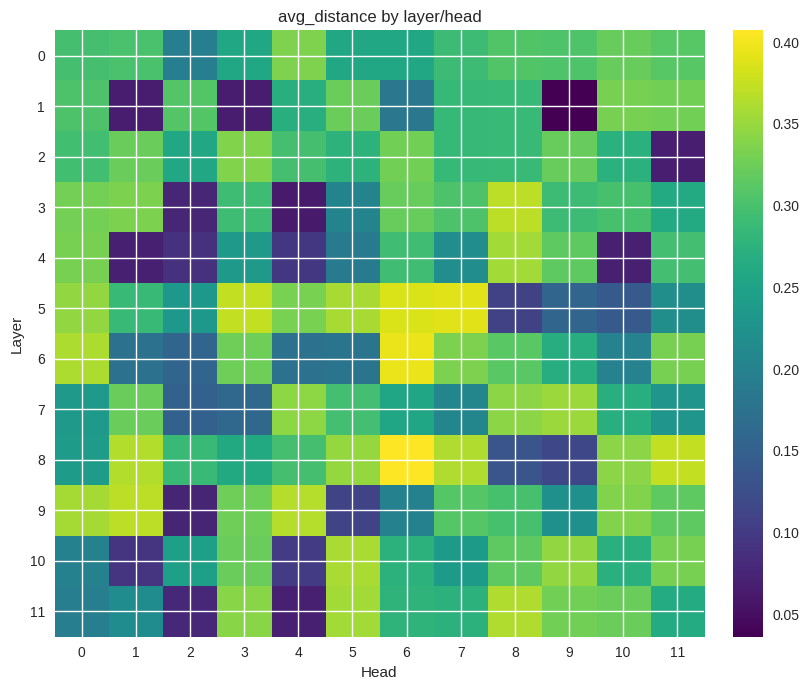

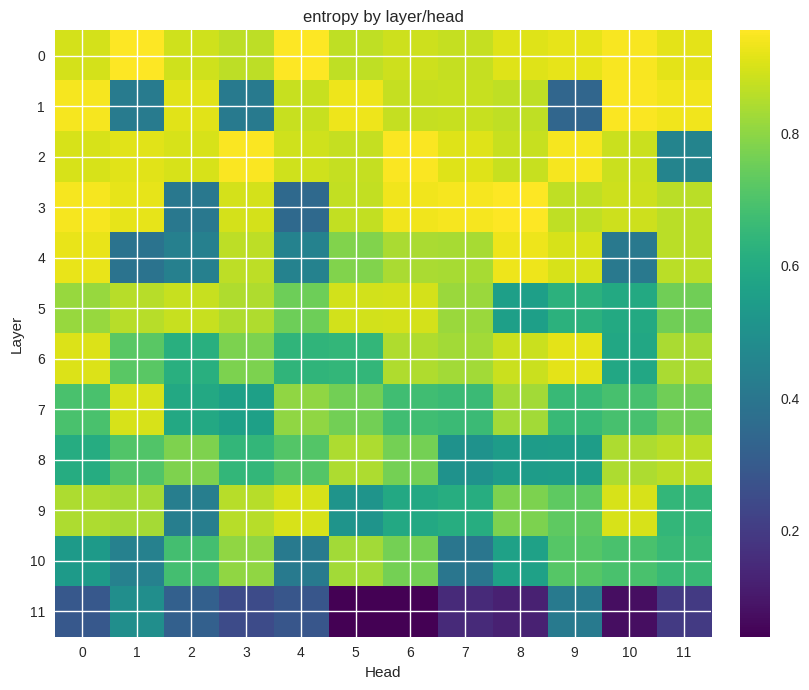

In [11]:
print("\n=== Wav2Vec2 analysis (audio) ===")
demo_wav2vec2()